# 14.03 — Topic Extractor Baselines (Keyword / Rule & TF-IDF)

This notebook establishes baseline benchmarks for the automatic Topic Extraction system on the **frozen validation split** ($N=641$).

### Baselines Evaluated:
1. **Keyword / Rule-Based Baseline:** Exact and alias matching using ontology aliases, longest-match precedence, and explicit abstention.
2. **TF-IDF + Cosine Centroid Baseline:** Sublinear TF-IDF representation with L2-normalized class prototypes across all 111 canonical skills.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.topic_extraction.keyword_baseline import KeywordBaselineClassifier
from src.topic_extraction.tfidf_baseline import TfidfBaselineClassifier

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


## 1. Load Dataset Splits
*Note: Evaluated strictly on `data/topic_extraction/splits/validation.csv`. Test split remains completely frozen.*

In [2]:
train_path = PROJECT_ROOT / 'data' / 'topic_extraction' / 'splits' / 'train.csv'
val_path = PROJECT_ROOT / 'data' / 'topic_extraction' / 'splits' / 'validation.csv'

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print(f'Train set: {len(train_df)} rows')
print(f'Validation set: {len(val_df)} rows across {val_df["canonical_name"].nunique()} classes')


Train set: 3186 rows
Validation set: 641 rows across 111 classes


## 2. Keyword / Rule-Based Baseline Evaluation

In [3]:
keyword_clf = KeywordBaselineClassifier()
kw_metrics = keyword_clf.evaluate(val_df)

kw_results_df = pd.DataFrame([
    {'Metric': 'Total Validation Samples', 'Value': f'{int(kw_metrics["total_samples"]):,}'},
    {'Metric': 'Covered Samples (Predictions Made)', 'Value': f'{int(kw_metrics["covered_samples"]):,}'},
    {'Metric': 'Validation Accuracy (Overall)', 'Value': f'{kw_metrics["accuracy"]*100:.2f}%'},
    {'Metric': 'Macro F1-Score', 'Value': f'{kw_metrics["macro_f1"]:.4f}'},
    {'Metric': 'Coverage Rate', 'Value': f'{kw_metrics["coverage"]*100:.2f}%'},
    {'Metric': 'Abstention Rate', 'Value': f'{kw_metrics["abstention_rate"]*100:.2f}%'},
    {'Metric': 'Covered-Example Accuracy (Precision)', 'Value': f'{kw_metrics["covered_accuracy"]*100:.2f}%'},
])

kw_results_df


,Metric,Value
0,Total Validation Samples,641
1,Covered Samples (Predictions Made),566
2,Validation Accuracy (Overall),87.83%
3,Macro F1-Score,0.8948
4,Coverage Rate,88.30%
5,Abstention Rate,11.70%
6,Covered-Example Accuracy (Precision),99.47%


## 3. TF-IDF + Cosine Centroid Baseline Evaluation

In [4]:
tfidf_clf = TfidfBaselineClassifier()
tfidf_clf.fit(train_df)
tfidf_clf.save_artifacts()

tfidf_metrics = tfidf_clf.evaluate(val_df)

tfidf_results_df = pd.DataFrame([
    {'Metric': 'Total Validation Samples', 'Value': f'{tfidf_metrics["total_samples"]:,}'},
    {'Metric': 'Validation Accuracy (Top-1)', 'Value': f'{tfidf_metrics["accuracy"]*100:.2f}%'},
    {'Metric': 'Top-3 Accuracy', 'Value': f'{tfidf_metrics["top3_accuracy"]*100:.2f}%'},
    {'Metric': 'Macro F1-Score', 'Value': f'{tfidf_metrics["macro_f1"]:.4f}'},
    {'Metric': 'Weighted F1-Score', 'Value': f'{tfidf_metrics["weighted_f1"]:.4f}'},
    {'Metric': 'Mean Top-1 Similarity', 'Value': f'{tfidf_metrics["mean_top1_similarity"]:.4f}'},
    {'Metric': 'Mean Top-1 / Top-2 Margin', 'Value': f'{tfidf_metrics["mean_margin"]:.4f}'},
])

tfidf_results_df


,Metric,Value
0,Total Validation Samples,641
1,Validation Accuracy (Top-1),95.94%
2,Top-3 Accuracy,97.97%
3,Macro F1-Score,0.9654
4,Weighted F1-Score,0.9585
5,Mean Top-1 Similarity,0.5291
6,Mean Top-1 / Top-2 Margin,0.2973


## 4. Comparative Analysis: Keyword vs TF-IDF

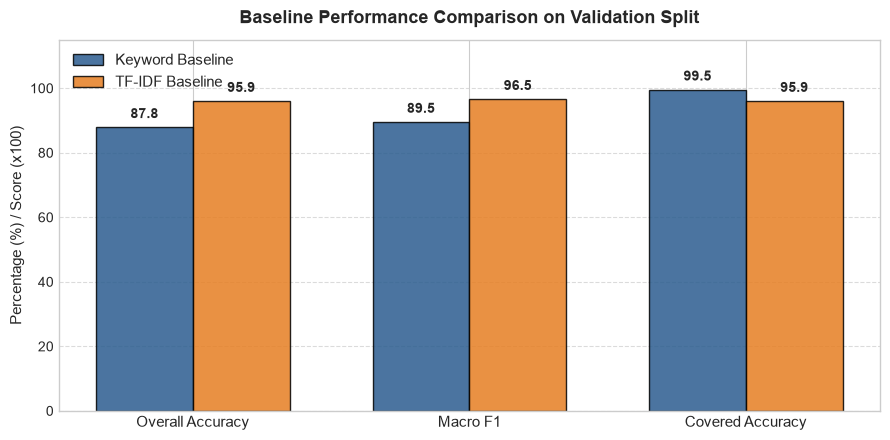

,Metric,Keyword Baseline,TF-IDF Baseline
0,Overall Accuracy,87.83%,95.94%
1,Macro F1,0.8948,0.9654
2,Coverage,88.30%,100.00%
3,Abstention Rate,11.70%,0.00%
4,Covered Accuracy,99.47%,95.94%


In [5]:
comparison_df = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Macro F1', 'Coverage', 'Abstention Rate', 'Covered Accuracy'],
    'Keyword Baseline': [
        f'{kw_metrics["accuracy"]*100:.2f}%',
        f'{kw_metrics["macro_f1"]:.4f}',
        f'{kw_metrics["coverage"]*100:.2f}%',
        f'{kw_metrics["abstention_rate"]*100:.2f}%',
        f'{kw_metrics["covered_accuracy"]*100:.2f}%',
    ],
    'TF-IDF Baseline': [
        f'{tfidf_metrics["accuracy"]*100:.2f}%',
        f'{tfidf_metrics["macro_f1"]:.4f}',
        '100.00%',
        '0.00%',
        f'{tfidf_metrics["accuracy"]*100:.2f}%',
    ],
})

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_width = 0.35
indices = np.arange(3)

rects1 = ax.bar(indices - bar_width/2, [kw_metrics['accuracy']*100, kw_metrics['macro_f1']*100, kw_metrics['covered_accuracy']*100], bar_width, label='Keyword Baseline', color='#2b5c8f', edgecolor='black', alpha=0.85)
rects2 = ax.bar(indices + bar_width/2, [tfidf_metrics['accuracy']*100, tfidf_metrics['macro_f1']*100, tfidf_metrics['accuracy']*100], bar_width, label='TF-IDF Baseline', color='#e67e22', edgecolor='black', alpha=0.85)

ax.set_ylabel('Percentage (%) / Score (x100)', fontsize=11)
ax.set_title('Baseline Performance Comparison on Validation Split', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(indices)
ax.set_xticklabels(['Overall Accuracy', 'Macro F1', 'Covered Accuracy'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rect in list(rects1) + list(rects2):
    y = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, y + 2, f'{y:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

comparison_df


## 5. Top Confusion Pairs in TF-IDF Predictions

In [6]:
y_true = tfidf_metrics['y_true']
y_pred = tfidf_metrics['y_pred']

mismatches = []
for yt, yp, text in zip(y_true, y_pred, val_df['text']):
    if yt != yp:
        mismatches.append({'True Skill': yt, 'Predicted Skill': yp, 'Text': text})

mismatch_df = pd.DataFrame(mismatches)
if len(mismatch_df) > 0:
    top_confusions = mismatch_df.groupby(['True Skill', 'Predicted Skill']).size().reset_index(name='Count').sort_values('Count', ascending=False)
    print(f'Total Validation Errors: {len(mismatch_df)} / {len(val_df)} ({len(mismatch_df)/len(val_df)*100:.2f}%)')
    print('\nTop Confusion Pairs:')
    display(top_confusions.head(10))
else:
    print('Zero errors found on validation split.')


Total Validation Errors: 26 / 641 (4.06%)

Top Confusion Pairs:


,True Skill,Predicted Skill,Count
17,math :: number sense & operations :: order of ...,math :: statistics & probability :: d.4.8-unde...,3
22,math :: statistics & probability :: venn diagram,math :: statistics & probability :: mean,2
0,math :: algebra & functions :: linear equations,math :: algebra & functions :: solving systems...,1
3,math :: algebra & functions :: slope,math :: statistics & probability :: table,1
4,math :: algebra & functions :: solving systems...,math :: algebra & functions :: solving for a v...,1
1,math :: algebra & functions :: linear equations,math :: proportional reasoning & percents :: p...,1
2,math :: algebra & functions :: slope,math :: algebra & functions :: finding slope f...,1
6,math :: geometry & measurement :: congruence,math :: algebra & functions :: equation solvin...,1
5,math :: algebra & functions :: solving systems...,math :: geometry & measurement :: unit convers...,1
7,math :: geometry & measurement :: congruence,math :: geometry & measurement :: calculations...,1
